<a href="https://colab.research.google.com/github/hsultova/Softuni-AI-Agents-Workflows/blob/main/exercises/langgraph_multi_agent_systems.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q langchain langchain-openai

In [2]:
from typing import TypedDict
from IPython.display import Image

from langgraph.graph import START, END, StateGraph
from langgraph.checkpoint.memory import InMemorySaver

In [3]:
class SystemState(TypedDict):
  route: str

In [4]:
def a_node(state: SystemState):
  print("Executing A node....")

def b_node(state: SystemState):
  print("Executing B node....")

def main_node(state: SystemState):
  print("Executing MAIN node....")

In [5]:
a_node_key = "a_node";
b_node_key = "b_node";
main_node_key = "main_node";

In [6]:
def route_decision(state: SystemState) -> str:
  if "A" in state.get("route"):
    return "path_a"
  return "path_b"

In [7]:
checkpointer = InMemorySaver()

In [8]:
graph_builder = StateGraph(SystemState)
graph_builder.add_node(main_node_key, main_node)
graph_builder.add_node(a_node_key, a_node)
graph_builder.add_node(b_node_key, b_node)

graph_builder.add_edge(START, main_node_key)
# Executing nodes simultaneously
graph_builder.add_edge(main_node_key, a_node_key)
graph_builder.add_edge(main_node_key, b_node_key)

# Executing conditional nodes
# graph_builder.add_conditional_edges(main_node_key, route_decision,
#     {
#       "path_a": a_node_key,
#       "path_b": b_node_key,
#     })
graph_builder.add_edge(a_node_key, END)
graph_builder.add_edge(b_node_key, END)
graph = graph_builder.compile(checkpointer)

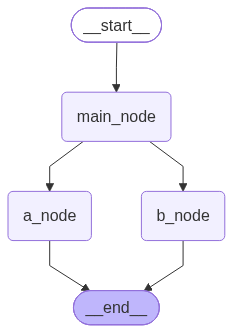

In [9]:
display(Image(data=graph.get_graph().draw_mermaid_png(), format="png"))

In [10]:
config = {"configurable":{"thread_id": "id_1"}}
state = SystemState(route="Go to path B")
graph.invoke(input=state, config=config)

Executing MAIN node....
Executing A node....
Executing B node....


{'route': 'Go to path B'}

In [11]:
list(checkpointer.list(config))

[CheckpointTuple(config={'configurable': {'thread_id': 'id_1', 'checkpoint_ns': '', 'checkpoint_id': '1f1ab772-843b-6d70-8002-80e62b2d72d9'}}, checkpoint={'v': 4, 'ts': '2026-09-08T11:19:29.018168+00:00', 'id': '1f1ab772-843b-6d70-8002-80e62b2d72d9', 'channel_versions': {'__start__': '00000000000000000000000000000002.0.8013275060647715', 'route': '00000000000000000000000000000002.0.8013275060647715', 'branch:to:main_node': '00000000000000000000000000000003.0.0974019878883039', 'branch:to:a_node': '00000000000000000000000000000004.0.648152372743892', 'branch:to:b_node': '00000000000000000000000000000004.0.648152372743892'}, 'versions_seen': {'__input__': {}, '__start__': {'__start__': '00000000000000000000000000000001.0.5511252675385659'}, 'main_node': {'branch:to:main_node': '00000000000000000000000000000002.0.8013275060647715'}, 'a_node': {'branch:to:a_node': '00000000000000000000000000000003.0.0974019878883039'}, 'b_node': {'branch:to:b_node': '00000000000000000000000000000003.0.0974

In [12]:
list(graph.get_state_history(config))

[StateSnapshot(values={'route': 'Go to path B'}, next=(), config={'configurable': {'thread_id': 'id_1', 'checkpoint_ns': '', 'checkpoint_id': '1f1ab772-843b-6d70-8002-80e62b2d72d9'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-09-08T11:19:29.018168+00:00', parent_config={'configurable': {'thread_id': 'id_1', 'checkpoint_ns': '', 'checkpoint_id': '1f1ab772-8435-6e66-8001-273a29a7a2e5'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'route': 'Go to path B'}, next=('a_node', 'b_node'), config={'configurable': {'thread_id': 'id_1', 'checkpoint_ns': '', 'checkpoint_id': '1f1ab772-8435-6e66-8001-273a29a7a2e5'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-09-08T11:19:29.015741+00:00', parent_config={'configurable': {'thread_id': 'id_1', 'checkpoint_ns': '', 'checkpoint_id': '1f1ab772-8432-6490-8000-345cb12396c8'}}, tasks=(PregelTask(id='e7a2c616-ade8-afde-d648-7e08b423c9a1', name='a_node', path=('__pregel_pull', 'a_node'), error=No